In [1]:
import numpy as np
from scipy.stats import norm
import matplotlib.pyplot as plt


def analytical_incoming_fee(L, theta, x, gamma, sigma, mu=0, delta_t=1/(365*24*60*5)):
    y = L**2 / x
    p0 = (y/x) * (1-gamma)**(-theta)
    
    d1 = (np.log((1-gamma) * y / (p0 * x)) - mu * delta_t) / (sigma * np.sqrt(delta_t))
    d2 = (np.log(y / ((1-gamma) * x * p0)) - mu * delta_t) / (sigma * np.sqrt(delta_t))
    
    alpha = L*np.sqrt((1-gamma)*p0) * np.exp(mu/2 - sigma**2/8 * delta_t)
    
    incoming_fee = gamma/(1-gamma) * (
        alpha * (norm.cdf(d1) + norm.cdf(-d2)) -\
        np.exp(mu*delta_t)*p0*x*norm.cdf(d1 - sigma*np.sqrt(delta_t)/2) -\
        y*norm.cdf(-d2 - sigma*np.sqrt(delta_t)/2)
        )
    
    return incoming_fee

def analytical_outgoing_fee(L, theta, x, gamma, sigma, mu, delta_t=1/(365*24*60*5)):
    y = L**2 / x
    p0 = (y/x) * (1-gamma)**(-theta)
    
    y = L**2 / x
    
    d1 = (np.log((1-gamma) * y / (p0 * x)) - mu * delta_t) / (sigma * np.sqrt(delta_t))
    d2 = (np.log(y / ((1-gamma) * x * p0)) - mu * delta_t) / (sigma * np.sqrt(delta_t))
    
    alpha = L*np.sqrt(p0/(1-gamma)) * np.exp(mu/2 - sigma**2/8 * delta_t)
    
    return gamma * (
        - alpha * (norm.cdf(d1) + norm.cdf(-d2)) +\
        np.exp(mu*delta_t)*p0*x*norm.cdf(-d2 + sigma*np.sqrt(delta_t)/2) +\
        y*norm.cdf(d1 + sigma*np.sqrt(delta_t)/2)
        )

def get_theta_distribution(sigma_val, gamma_val, sigmas, gammas, counts):
    """
    Get the count vector for a specific (sigma, gamma) combination.
    
    Args:
        sigma_val: target sigma value
        gamma_val: target gamma value
        sigmas: array of sigma values from the data
        gammas: array of gamma values from the data
        counts: 3D array of shape (num_sigmas, num_gammas, num_bins)
    
    Returns:
        1D array of counts for each bin
    """
    # Find sigma index
    si_matches = np.where(np.isclose(sigmas, sigma_val))[0]
    if len(si_matches) == 0:
        raise ValueError(f"sigma={sigma_val} not found in data")
    si = si_matches[0]
    
    # Find gamma index
    gi_matches = np.where(np.isclose(gammas, gamma_val))[0]
    if len(gi_matches) == 0:
        raise ValueError(f"gamma={gamma_val} not found in data")
    gi = gi_matches[0]
    
    # Return the count vector for this (sigma, gamma) pair
    return counts[si, gi, :]

# Convert counts to relative frequencies (probabilities)
def get_theta_probabilities(sigma_val, gamma_val, sigmas, gammas, counts):
    """
    Get the probability vector for a specific (sigma, gamma) combination.
    
    Args:
        sigma_val: target sigma value
        gamma_val: target gamma value
        sigmas: array of sigma values from the data
        gammas: array of gamma values from the data
        counts: 3D array of shape (num_sigmas, num_gammas, num_bins)
    
    Returns:
        1D array of probabilities for each bin (sums to 1)
    """
    theta_counts = get_theta_distribution(sigma_val, gamma_val, sigmas, gammas, counts)
    total_counts = theta_counts.sum()
    
    if total_counts == 0:
        return np.zeros_like(theta_counts, dtype=float)
    
    theta_probs = theta_counts.astype(float) / total_counts
    return theta_probs

In [8]:
import pandas as pd
from tqdm import tqdm
import numpy as np

npz_path = "/home/shiftpub/Dynamic_AMM/theta_hist_out/hists_20250916_104317.npz"
# npz_path = "/home/shiftpub/Dynamic_AMM/theta_hist_out/lower_gamma.npz"
data = np.load(npz_path)
edges = data['bin_edges']
sigmas = data['sigmas']
gammas = data['gammas']
counts = data['counts']
# Load underflow and overflow data
underflow = data['underflow']  # shape: (n_sigma, n_gamma)
overflow = data['overflow']    # shape: (n_sigma, n_gamma)

# add the overflow to the last bin
counts[:, :, -1] += overflow

x = 1_000_000_000
L = 1_000_000_000
mu = 0
results = []
total_combinations = len(sigmas) * len(gammas)
progress_bar = tqdm(total=total_combinations, desc="Progress")
for i in range(len(sigmas)):
    for j in range(len(gammas)):
        sigma = sigmas[i]
        gamma = gammas[j]
        theta_probs = get_theta_probabilities(sigma, gamma, sigmas, gammas, counts)
        for k in range(len(theta_probs)):
            theta = edges[k]
            incoming_fee = analytical_incoming_fee(L, theta, x, gamma, sigma, mu)
            outgoing_fee = analytical_outgoing_fee(L, theta, x, gamma, sigma, mu)
            results.append({
                'theta': theta,
                'theta_probs': theta_probs[k],
                'sigma': sigma,
                'gamma': gamma,
                'incoming_fee': incoming_fee,
                'outgoing_fee': outgoing_fee
            })
        progress_bar.update(1)
progress_bar.close()



results = pd.DataFrame(results)
results.to_csv('theta_distribution_results.csv', index=False)

Progress: 100%|██████████| 2691/2691 [09:04<00:00,  4.94it/s]


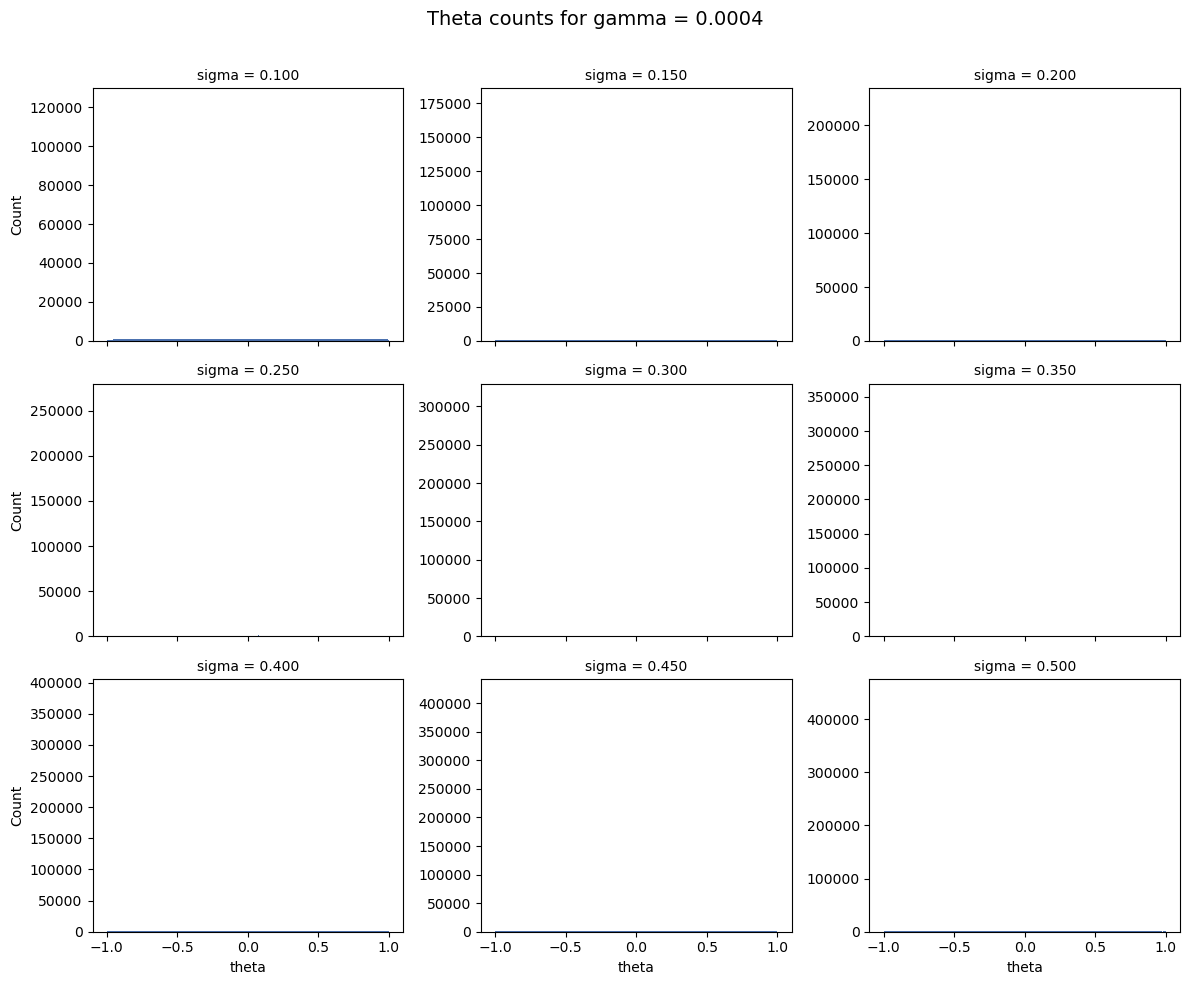

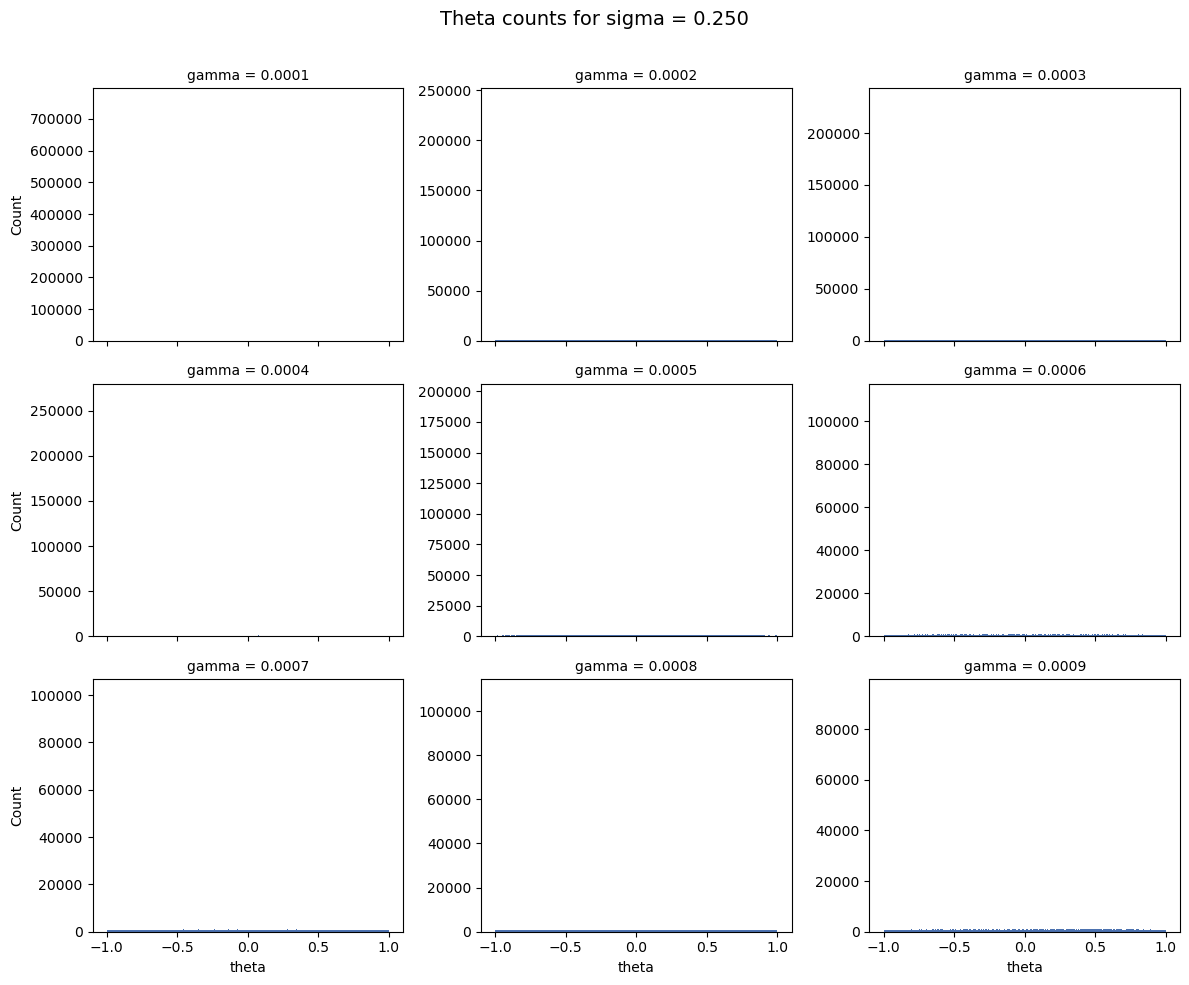

In [7]:
# 3x3 histograms with TOTAL COUNTS for all sigmas, gamma fixed at 0.03, y-axes independent
gamma_target = gammas[3]
gi_matches = np.where(np.isclose(gammas, gamma_target))[0]
if len(gi_matches) == 0:
    raise ValueError("gamma=0.0005 not found in loaded 'gammas'")
gi = gi_matches[0]
gamma_val = gammas[gi]

ctr = (edges[:-1] + edges[1:]) / 2
bin_width = edges[1] - edges[0]

fig, axes = plt.subplots(3, 3, figsize=(12, 10), sharex=True)  # do not share y
axes = axes.ravel()
_sub_sigmas = sigmas[:9]
for si, sigma_val in enumerate(_sub_sigmas):
    ax = axes[si]
    ax.bar(ctr, counts[si, gi], width=bin_width, color="#4C72B0")
    ax.set_title(f"sigma = {sigma_val:.3f}", fontsize=10)
    if si % 3 == 0:
        ax.set_ylabel("Count")
    if si // 3 == 2:
        ax.set_xlabel("theta")

for k in range(len(sigmas), 9):
    fig.delaxes(axes[k])

fig.suptitle(f"Theta counts for gamma = {gamma_val:.4f}", fontsize=14)
plt.tight_layout(rect=[0, 0, 1, 0.97])
plt.show()


# 3x3 histograms with TOTAL COUNTS for all gammas, sigma fixed at 0.1, y-axes independent
sigma_target = sigmas[3]
si_matches = np.where(np.isclose(sigmas, sigma_target))[0]
if len(si_matches) == 0:
    raise ValueError("sigma=0.1 not found in loaded 'sigmas'")
si = si_matches[0]
sigma_val = sigmas[si]

ctr = (edges[:-1] + edges[1:]) / 2
bin_width = edges[1] - edges[0]

fig, axes = plt.subplots(3, 3, figsize=(12, 10), sharex=True)  # do not share y
axes = axes.ravel()
_sub_gammas = gammas[:9]
for gi, gamma_val in enumerate(_sub_gammas):
    ax = axes[gi]
    ax.bar(ctr, counts[si, gi], width=bin_width, color="#4C72B0")
    ax.set_title(f"gamma = {gamma_val:.4f}", fontsize=10)
    if gi % 3 == 0:
        ax.set_ylabel("Count")
    if gi // 3 == 2:
        ax.set_xlabel("theta")

for k in range(len(gammas), 9):
    fig.delaxes(axes[k])

fig.suptitle(f"Theta counts for sigma = {sigma_val:.3f}", fontsize=14)
plt.tight_layout(rect=[0, 0, 1, 0.97])
plt.show()

|    |   sigma |   gamma |   expected_incoming_fee |   expected_outgoing_fee |
|---:|--------:|--------:|------------------------:|------------------------:|
|  0 |     0.1 |  0.0001 |                0.810786 |                0.811305 |
|  1 |     0.1 |  0.0002 |                0.8434   |                0.844088 |
|  2 |     0.1 |  0.0003 |                0.964826 |                0.964701 |
|  3 |     0.1 |  0.0004 |                1.14152  |                1.14473  |
|  4 |     0.1 |  0.0005 |                1.11296  |                1.11443  |


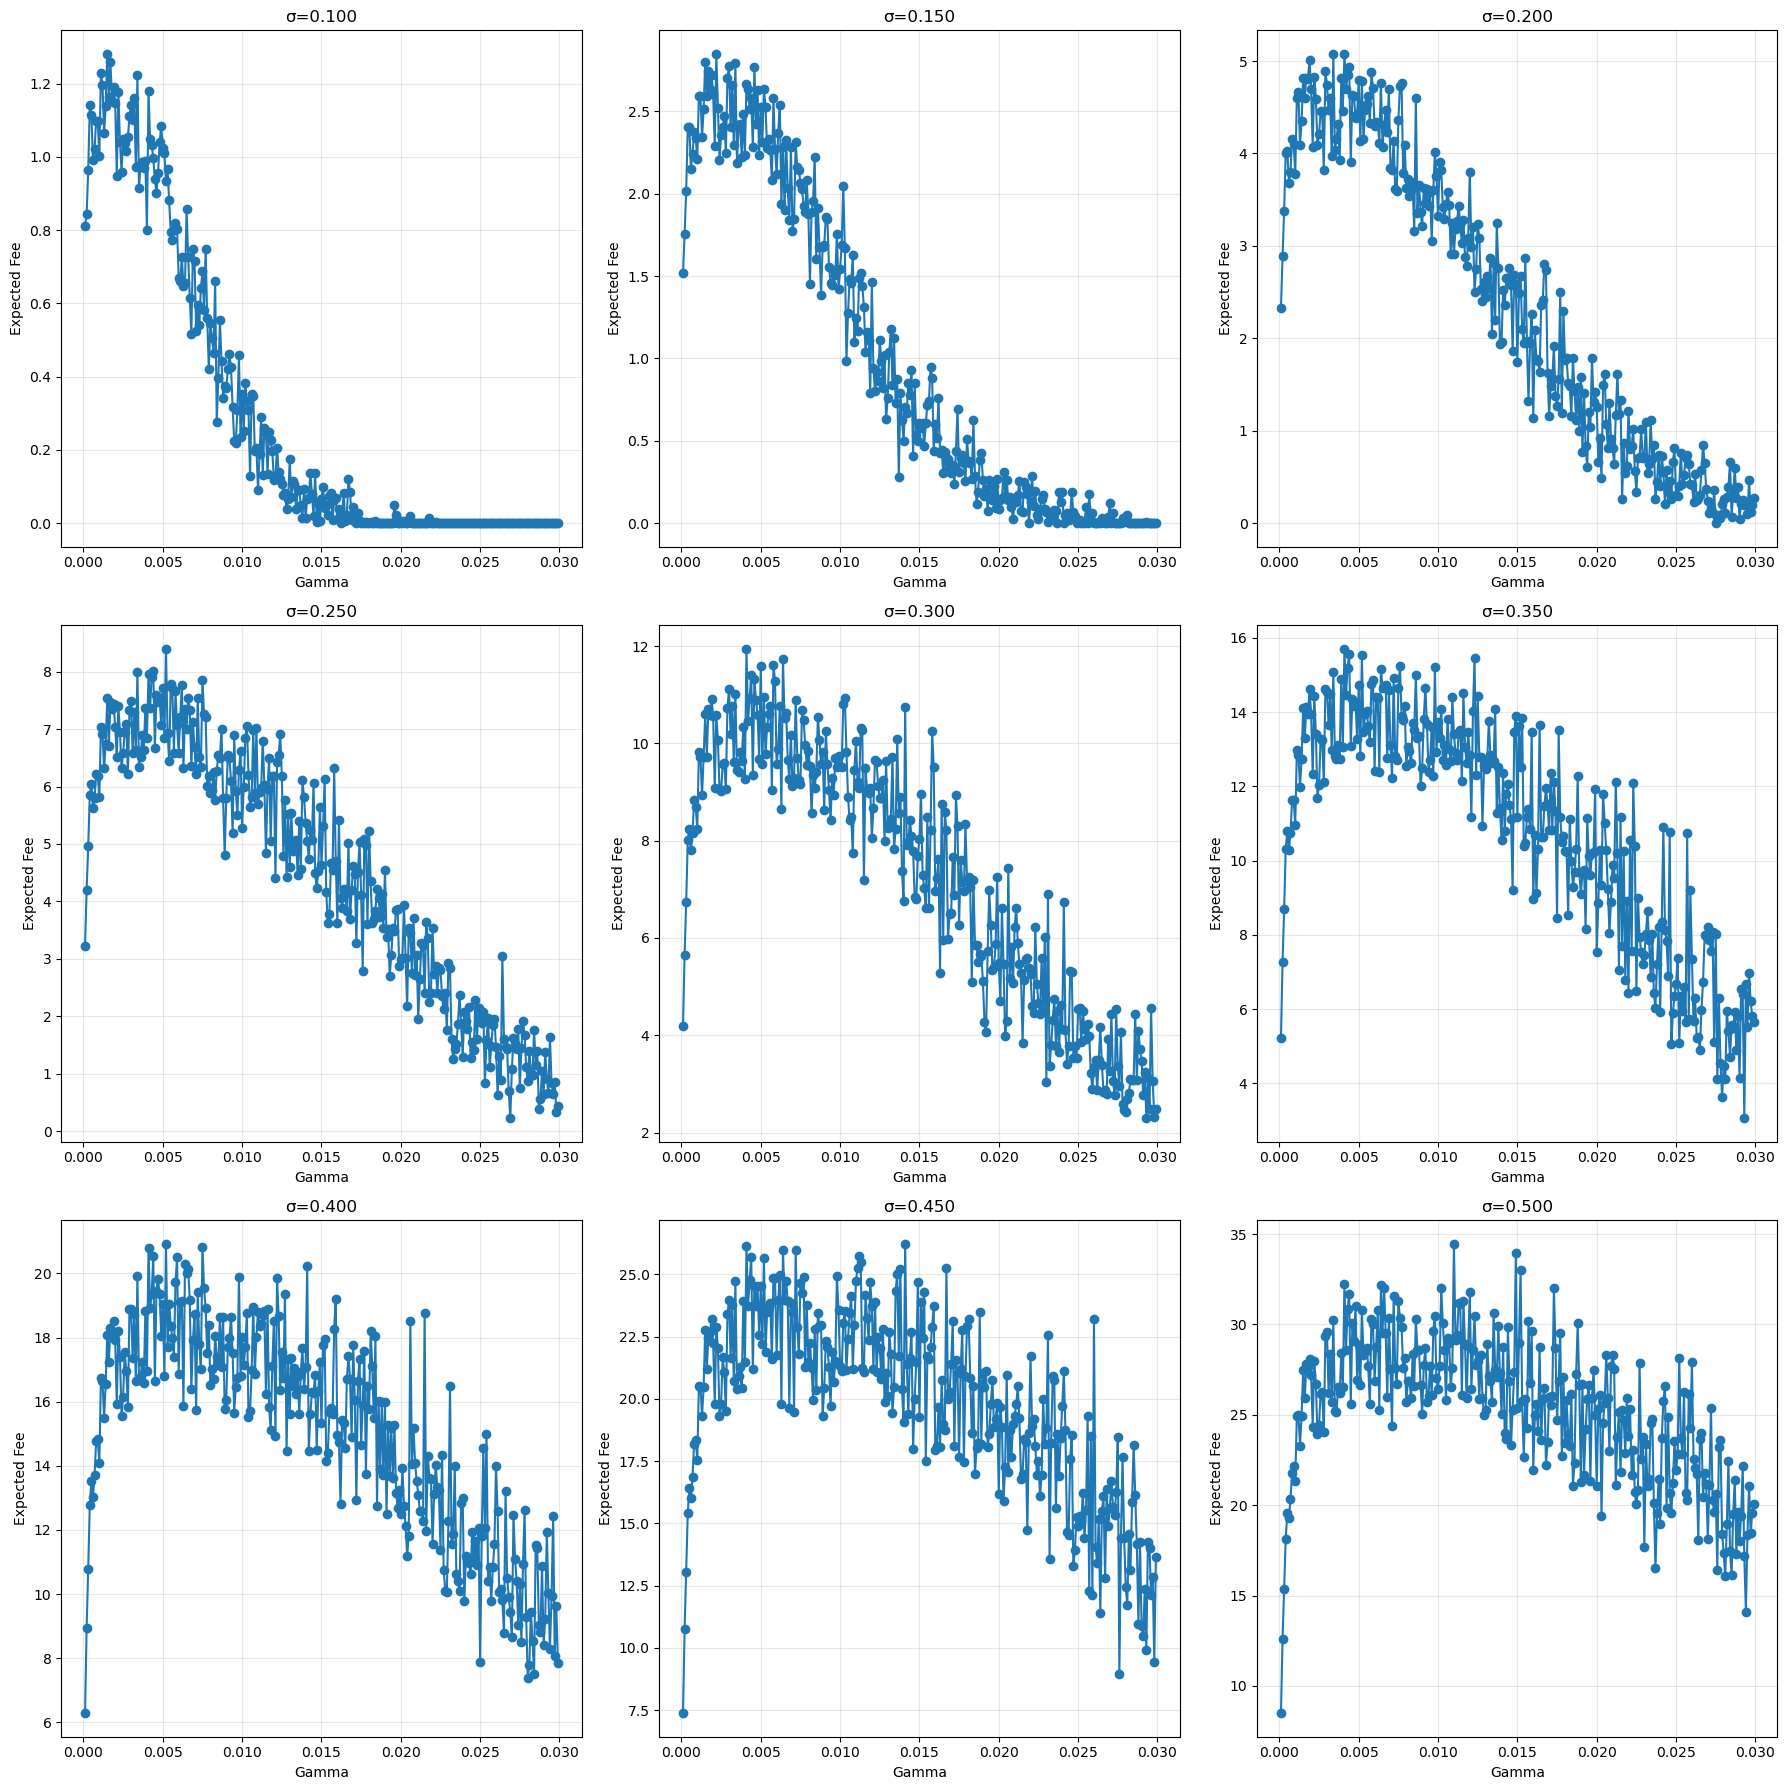

In [4]:
results['expected_incoming_fee'] = results['theta_probs'] * results['incoming_fee']
results['expected_outgoing_fee'] = results['theta_probs'] * results['outgoing_fee']

# create a data frame with columns sigma and gamma, and the expected fee, which is sum under this combination of parameters
results_df = results.groupby(['sigma', 'gamma']).agg({'expected_incoming_fee': 'sum', 'expected_outgoing_fee': 'sum'}).reset_index()
print(results_df.head().to_markdown())

import matplotlib.pyplot as plt
# plot x axis is gamma, y axis is the expected fee, different sigma in different subplots
fig, axes = plt.subplots(3, 3, figsize=(18, 18))
axes = axes.ravel()  # flatten to 1D for easier indexing

for i, sigma in enumerate(results_df['sigma'].unique()):
    if i < len(axes):  # ensure we don't exceed subplot count
        ax = axes[i]
        sigma_data = results_df[results_df['sigma'] == sigma]
        ax.plot(sigma_data['gamma'], sigma_data['expected_incoming_fee'], 'o-')
        # ax.plot(sigma_data['gamma'], sigma_data['expected_outgoing_fee'], 'x-', label='outgoing')
        ax.set_xlabel('Gamma')
        ax.set_ylabel('Expected Fee')
        ax.set_title(f'σ={sigma:.3f}')
        ax.grid(True, alpha=0.3)

# Hide unused subplots
for j in range(len(results_df['sigma'].unique()), len(axes)):
    axes[j].set_visible(False)

plt.tight_layout()
plt.show()



In [5]:
DT             = 1.0 / (365.0 * 24 * 60 * 5)
SIGMAS         = np.array([0.10, 0.15, 0.20, 0.25, 0.30, 0.35, 0.40, 0.45, 0.50], dtype=np.float32)
GAMMAS         = np.arange(0.0001, 0.03, 0.0001, dtype=np.float32)

mu = 0
x = 1_000_000_000
L = 1_000_000_000
no_theta_results = []
for i in range(len(SIGMAS)):
    for j in range(len(GAMMAS)):
        for theta in [-1, 0, 1]:
            sigma = SIGMAS[i]
            gamma = GAMMAS[j]
            incoming_fee = analytical_incoming_fee(L, theta, x, gamma, sigma, mu)
            outgoing_fee = analytical_outgoing_fee(L, theta, x, gamma, sigma, mu)
            no_theta_results.append({
                'sigma': sigma,
                'gamma': gamma,
                'incoming_fee': incoming_fee,
                'outgoing_fee': outgoing_fee,
                'theta': theta
            })

no_theta_results = pd.DataFrame(no_theta_results)
no_theta_results.to_csv('no_theta_results.csv', index=False)


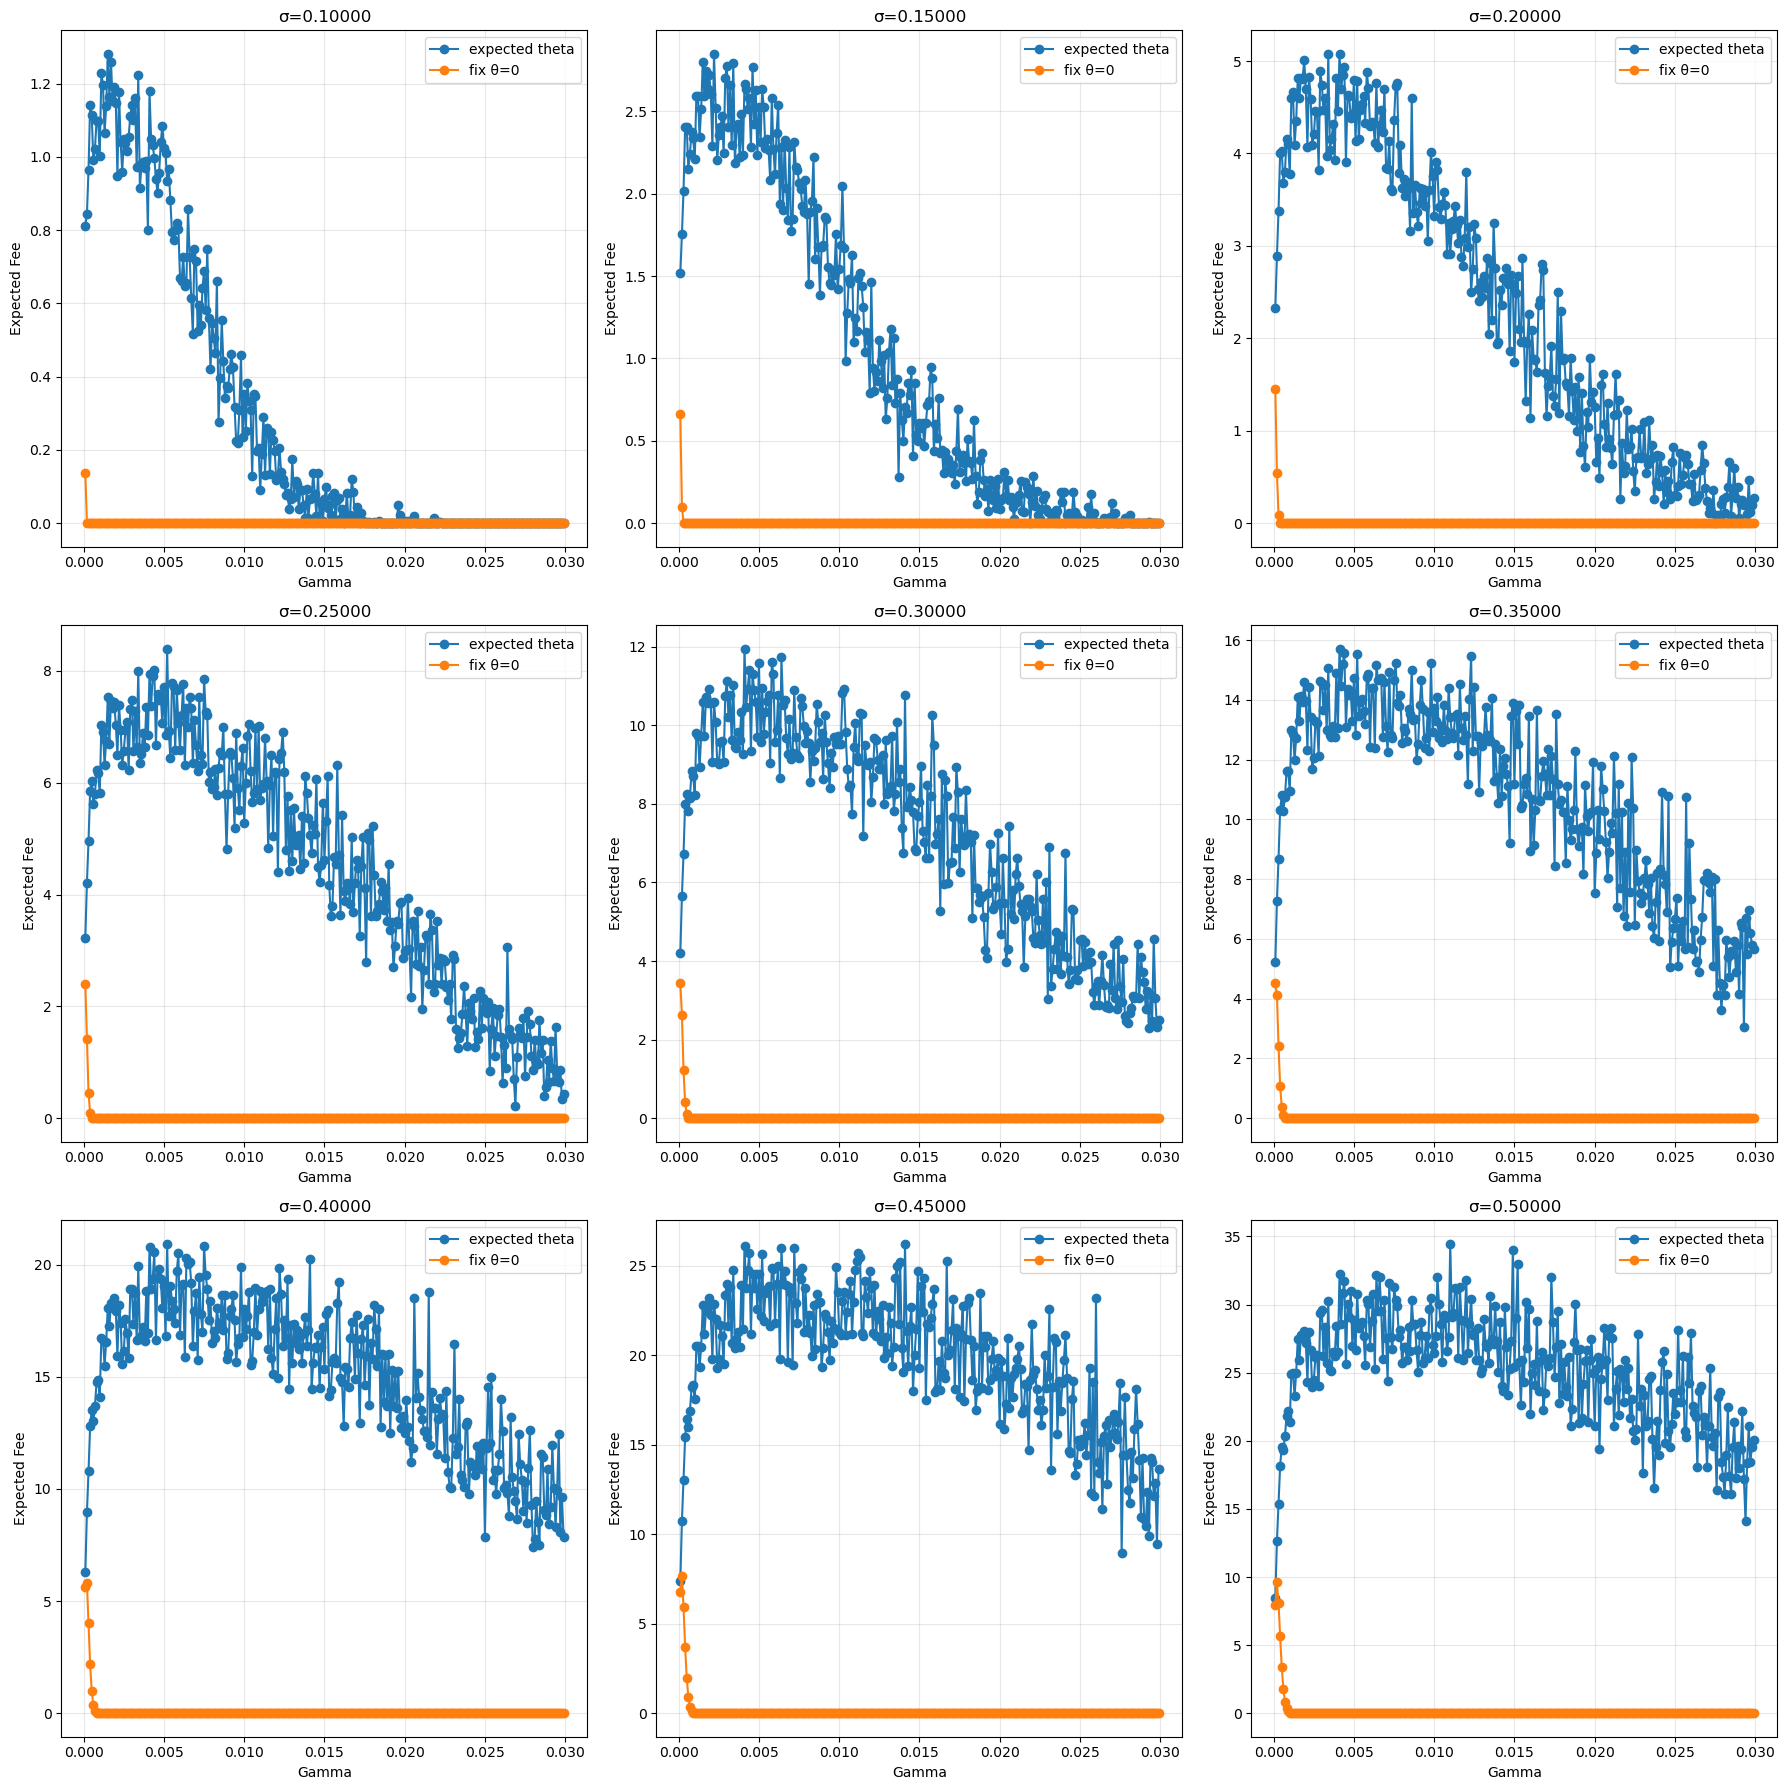

In [6]:
import matplotlib.pyplot as plt
# plot x axis is gamma, y axis is the expected fee, different sigma in different subplots
fig, axes = plt.subplots(3, 3, figsize=(18, 18))
axes = axes.ravel()  # flatten to 1D for easier indexing

for i, sigma in enumerate(no_theta_results['sigma'].unique()):
    if i < len(axes):  # ensure we don't exceed subplot count
        ax = axes[i]
        sigma_data = results_df[results_df['sigma'] == sigma]
        ax.plot(sigma_data['gamma'], sigma_data['expected_incoming_fee'], 'o-', label='expected theta')
        for theta in [0]:
            sub_theta_results = no_theta_results[(no_theta_results['theta'] == theta) & (no_theta_results['sigma'] == sigma)]
            ax.plot(sub_theta_results['gamma'], sub_theta_results['incoming_fee'], 'o-', label=f'fix θ={theta}')
        ax.set_xlabel('Gamma')
        ax.set_ylabel('Expected Fee')
        ax.set_title(f'σ={sigma:.5f}')
        ax.grid(True, alpha=0.3)
        ax.legend()

# Hide unused subplots
for j in range(len(results_df['sigma'].unique()), len(axes)):
    axes[j].set_visible(False)

plt.tight_layout()
plt.show()